In [1]:
import numpy as np
# import sympy as sp
from plotly import express as px
from matplotlib import pyplot as plt
import pandas as pd
import scipy as scp


#IGUAL PARA TODOS LOS EXPERIMENTOS AL MENOS DEL MIERCOLES PASADO QSY NO CREO QUE NADIE VAYA A LEER ESTO HOLA CUCHU

f_0=16.43e3

distd2=[7,16,25,43,54,71,90,110,130,150,170,190,210,230,250,270,290,300]

dia_2=pd.DataFrame(columns=['distd2','Voltajes_RMS_Osciloscopio','Voltajes_Lock_In_Virtual','Voltajes_fit',''])
dia_2_fitparams=pd.DataFrame(columns=['A','B','C','D','Error A','Error B','Error C','Error D'])

dick2=dict()

for i in range (1,19):
    if i<10:
        dick2[f'dato_{i}']= pd.read_csv(f'datosdia2/SDS0000{i}.CSV',header=1)[:-50] #CORTO EN -50 PORQUE TENIA UN ERROR QUE NO SE DE DONDE PORONGA SALIÓ
                                                                                   #bue por qué gritaba
        # print(f'SDS0000{i}')
    else:
        dick2[f'dato_{i}'] = pd.read_csv(f'datosdia2/SDS000{i}.CSV',header=1)[:-50]
        # print(f'SDS000{i}')

In [2]:
#########FUNCIONES

def funkfit (x,a,b,c,d):
    """ a*np.sin(2 pi* b * x + c )+d """
    return a*np.sin(2*np.pi*b*x+c)+d

def B_short(x,n,a,log=False):
    if log:
        return np.exp(a)*x**n
    else:    
        return a*x**n

def lock_in(datos,f):
    x,y =datos['Second'],datos['Volt.1']
    
    # print(x,'\n',y)
    dx=x.iloc[-1]-x.iloc[0]
    
    y_cos= np.cos(2*np.pi*f*x)* y
    y_sin= np.sin(2*np.pi*f*x)* y

    U_cos=1/dx*np.trapz(y_cos,x=x)
    U_sin=1/dx*np.trapz(y_sin,x=x)

    
    # plt.figure()
    # plt.plot(y_cos)
    r=((2*U_cos)**2+(2*U_sin)**2)**.5
    phi=np.arctan2(U_sin,U_cos)

    return r,phi

C:\Users\soysa\AppData\Local\Temp\ipykernel_6368\4182272406.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dia_2_fitparams = pd.concat([dia_2_fitparams, df_input])


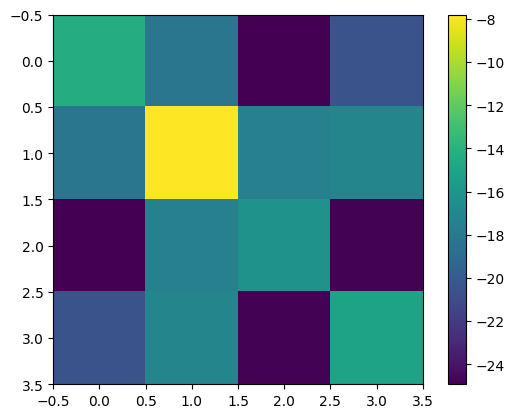

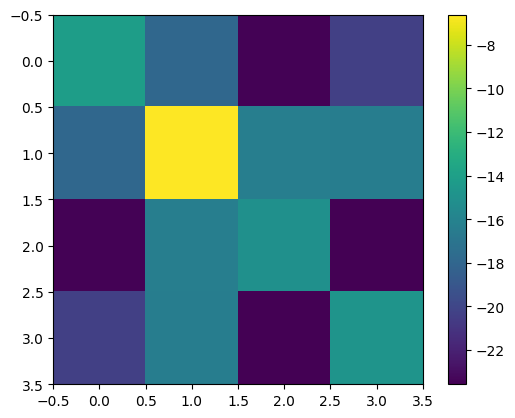

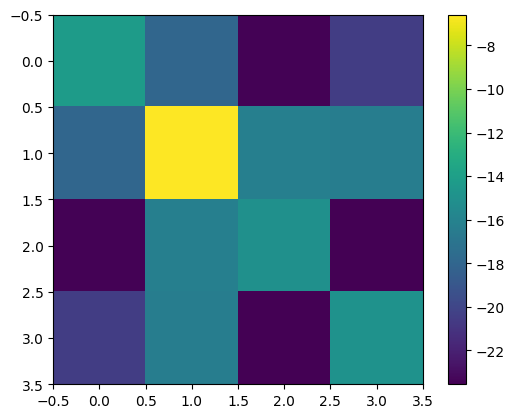

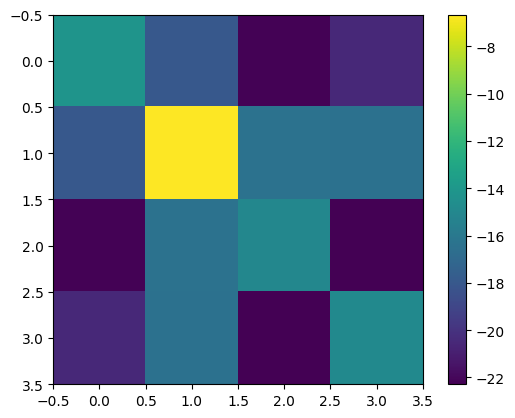

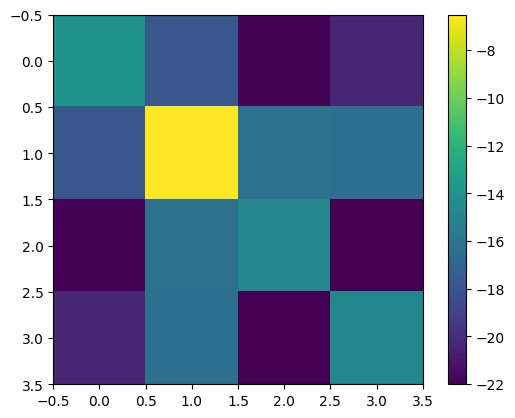

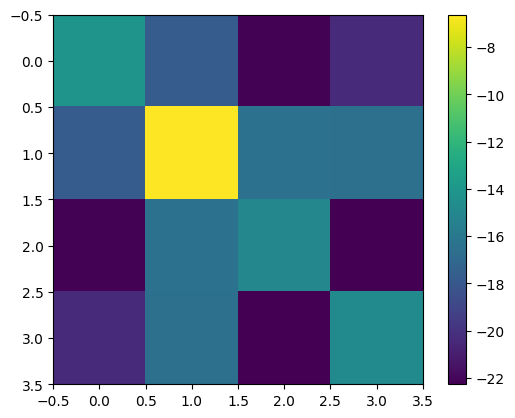

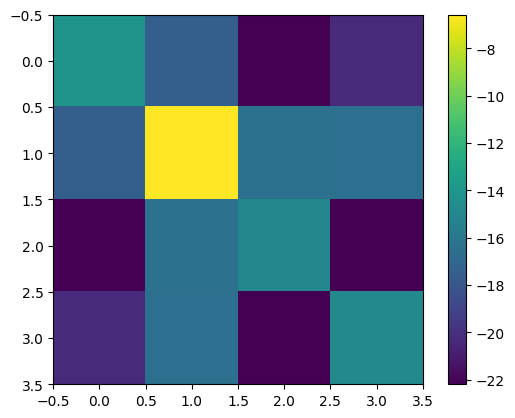

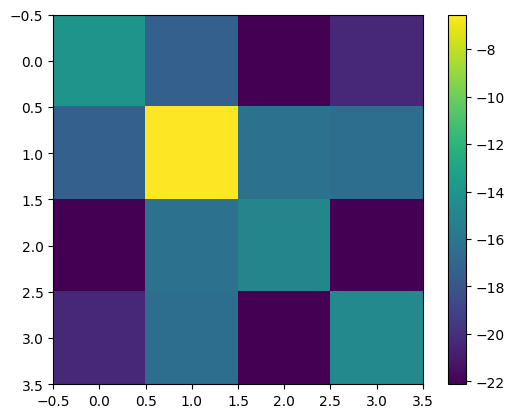

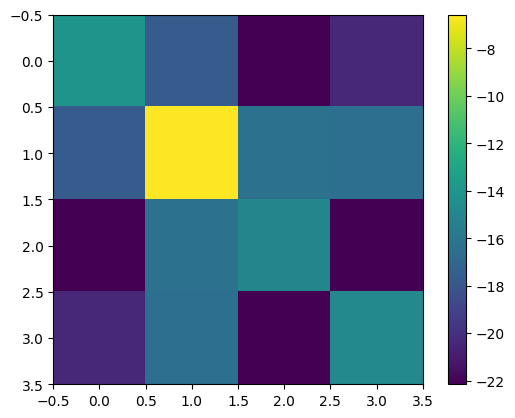

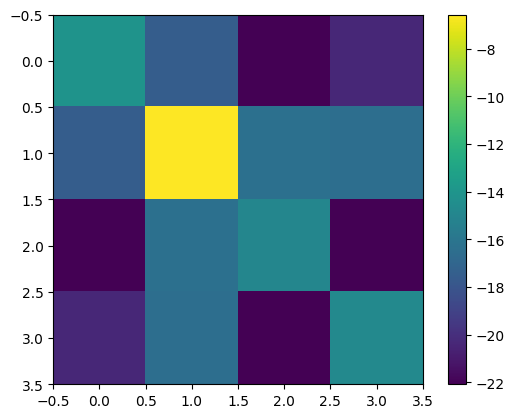

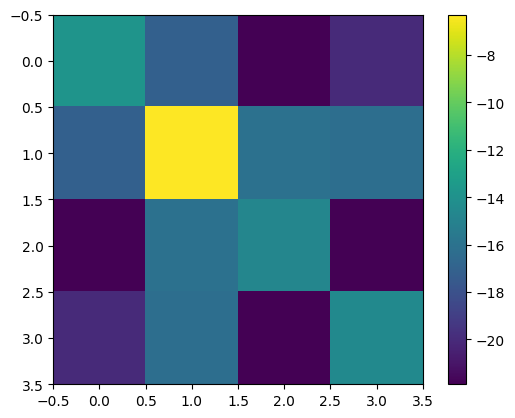

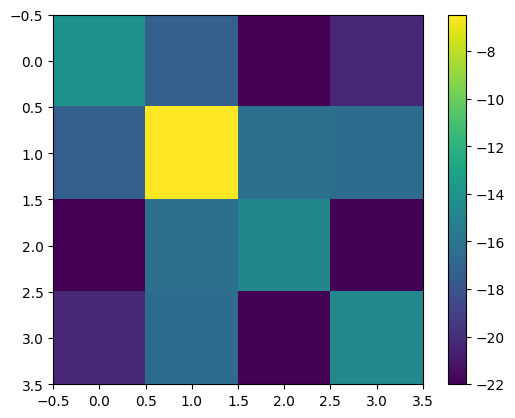

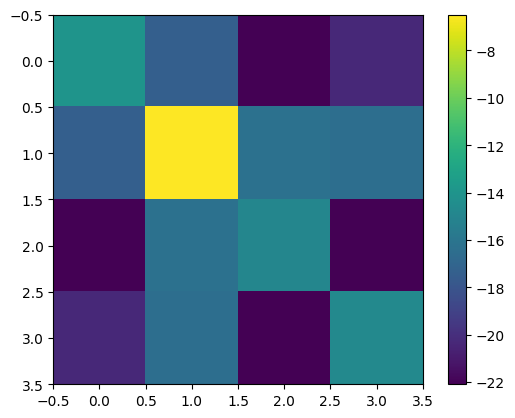

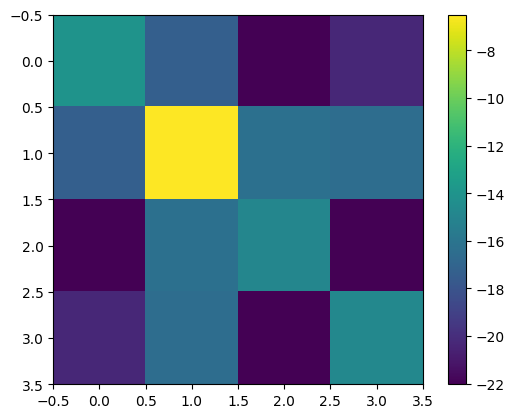

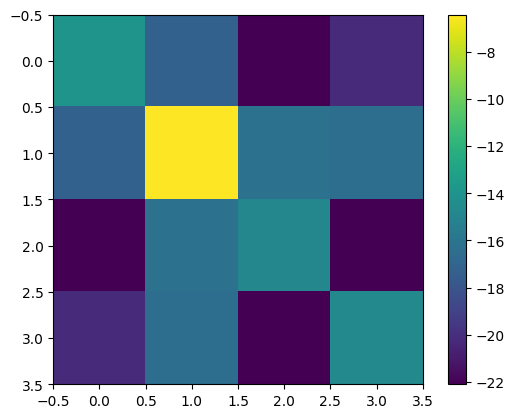

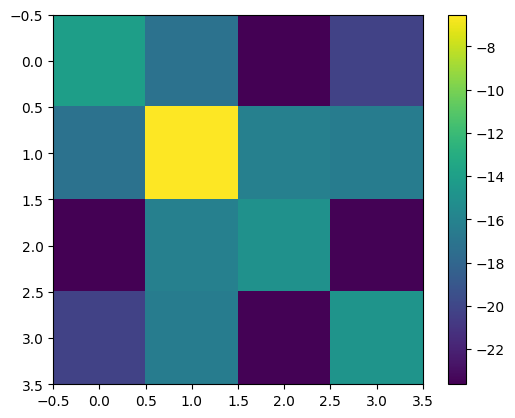

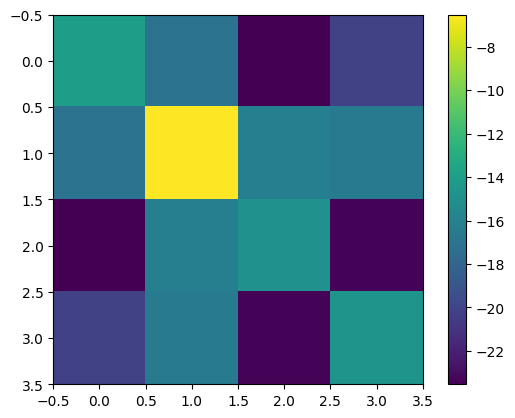

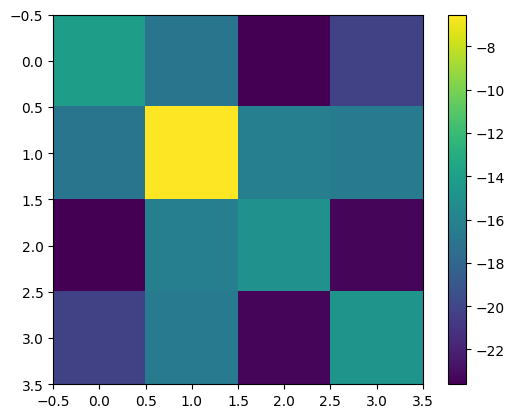

In [3]:
for i in range(1,19):
    x,y =dick2[f'dato_{i}']['Second'],dick2[f'dato_{i}']['Volt']
    
    p0=[0.660 , f_0 , 0 , 0] #el valor inicial es 0.660 porque fue el que medimos con el osciloscopio, a este no le mandé nada raro de lockin
    
    popt,pcov=scp.optimize.curve_fit(funkfit,xdata=x,ydata=y,p0=p0)
    
    pcovdiag=np.diag(pcov)
    
    data_row=np.array([np.concatenate([popt,pcovdiag])])
    
    df_input=pd.DataFrame(columns=dia_2_fitparams.columns,data=data_row)
    
    dia_2_fitparams = pd.concat([dia_2_fitparams, df_input])
    
    plt.figure()
    plt.imshow(np.log(np.abs(pcov)))
    plt.colorbar()

In [4]:
dia_2_fitparams

,A,B,C,D,Error A,Error B,Error C,Error D
0,2.574265,16358.942872,-0.491840,0.014214,5.970929e-07,0.000408,8.990701e-08,2.982236e-07
0,1.594162,16361.611572,-0.461909,0.010822,7.429145e-07,0.001325,2.916682e-07,3.710388e-07
0,1.490069,16361.779792,-0.458677,0.011559,6.723534e-07,0.001372,3.021346e-07,3.357974e-07
0,1.574770,16361.067299,-0.278238,0.001496,6.982580e-07,0.001276,2.810026e-07,3.487820e-07
0,1.543469,16360.497036,-0.240376,-0.001283,7.782886e-07,0.001481,3.260799e-07,3.887774e-07
0,1.552446,16359.736439,-0.286775,0.002383,7.059874e-07,0.001328,2.923537e-07,3.526479e-07
0,1.552132,16357.650296,-0.284602,-0.008985,7.365895e-07,0.001386,3.051799e-07,3.679514e-07
0,1.553214,16357.020565,-0.269964,0.000318,7.622191e-07,0.001433,3.153779e-07,3.807750e-07
0,1.554850,16359.101381,-0.269315,0.002629,7.358506e-07,0.001380,3.037959e-07,3.675774e-07
0,1.555569,16358.368007,-0.258141,0.006794,7.480347e-07,0.001402,3.085595e-07,3.736718e-07


In [5]:
V2=[]
for i,j in enumerate(range(1,19)):
    V2+=[lock_in(dick2[f'dato_{j}'],dia_2_fitparams.iloc[i,1])[0]]

Text(0, 0.5, 'Voltaje [V]')

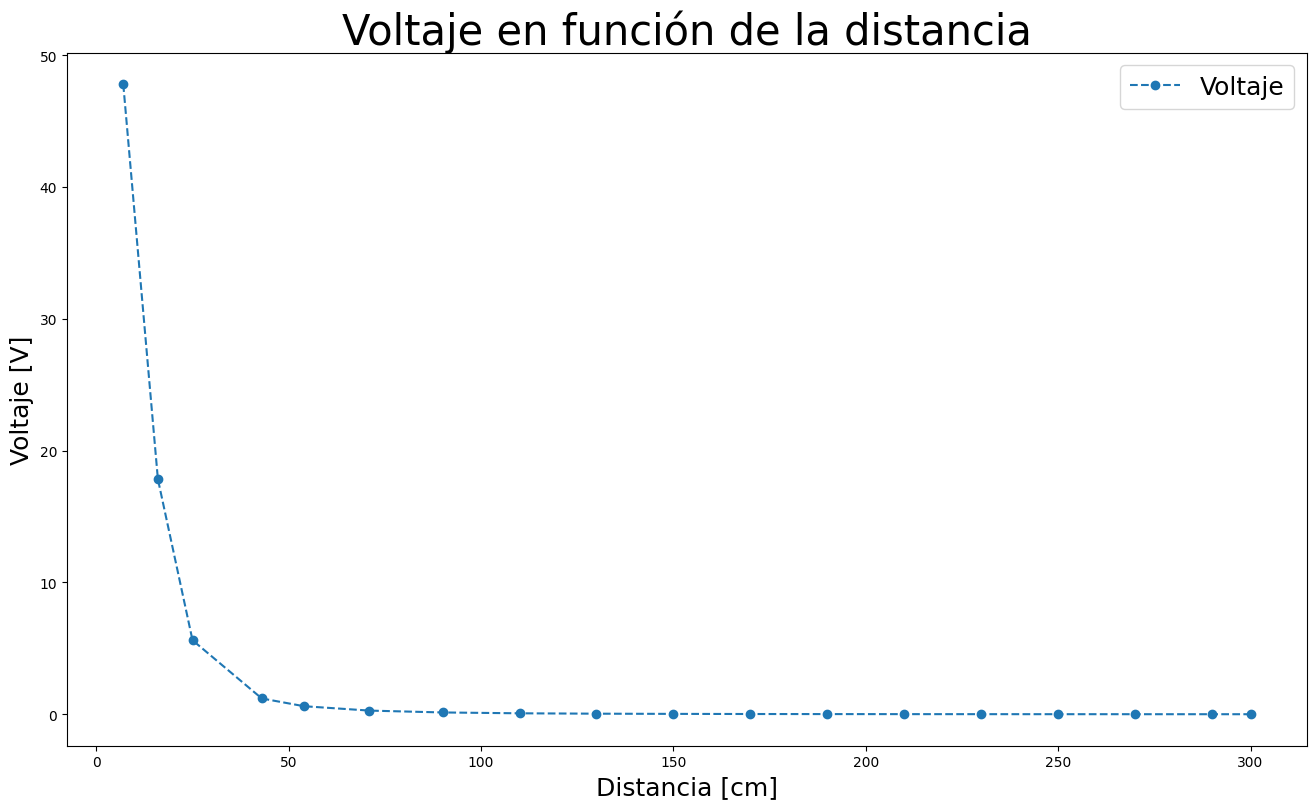

In [6]:
plt.figure(figsize=(16,9))
plt.plot(distd2,V2,'o--')

plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [7]:
P=np.polyfit(np.log(distd2[2:]),np.log(V2[2:]),1)
#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P


array([-2.95257154, 11.27144351])

Text(0, 0.5, 'Voltaje [V]')

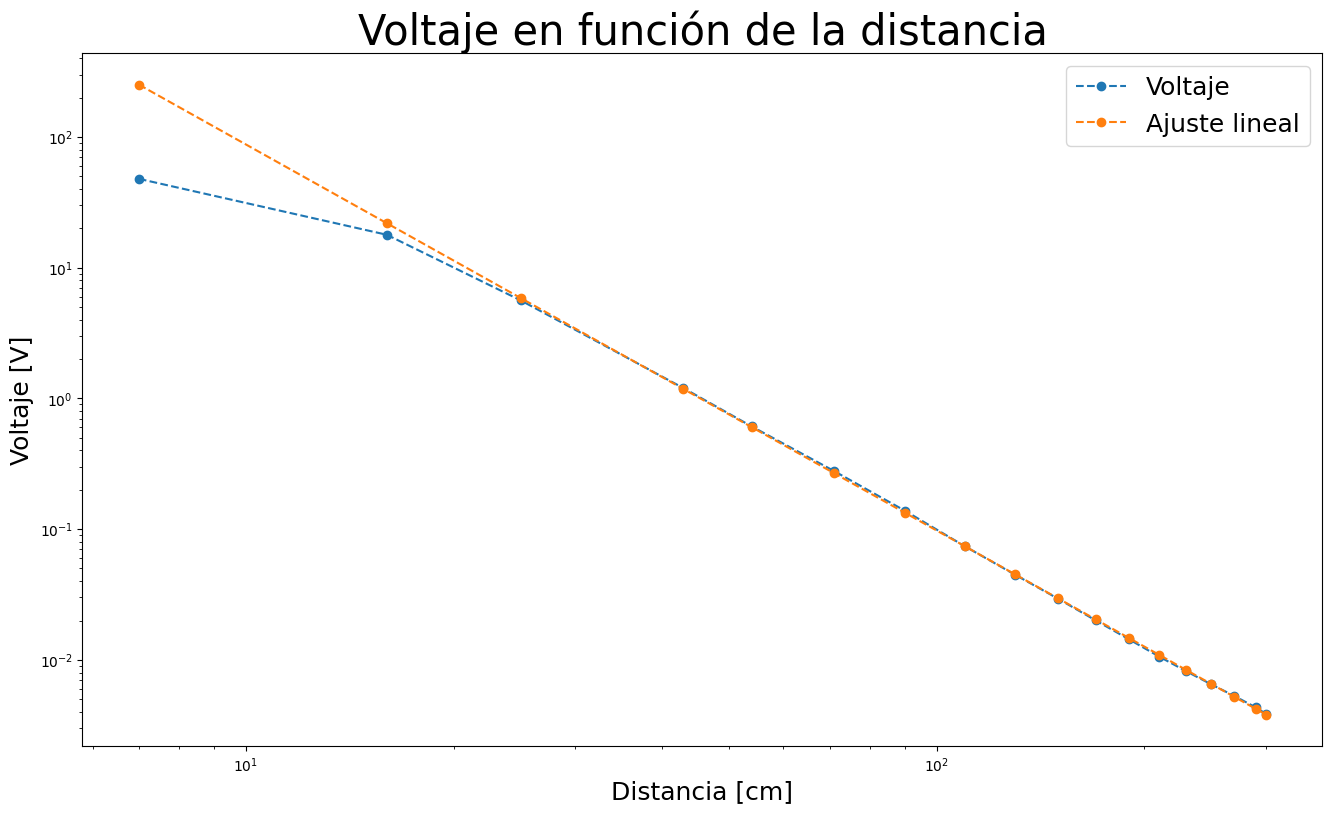

In [8]:
plt.figure(figsize=(16,9))
plt.loglog(distd2,V2,'o--')
plt.loglog(distd2,B_short(distd2,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [9]:
pd.DataFrame({'d':distd2,'V':V2}).to_csv('V_2.csv',index=False)